In [1]:
import numpy as np
import pandas as pd

In [2]:
fold0_05 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_fountains/fold0_0.5_all_data_extra.tsv", sep="\t")

fold0_05["fold"] = [0 for i in range(len(fold0_05))]
fold0_05["target"] = [-0.5 for i in range(len(fold0_05))]

In [3]:
fold1_05 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_fountains/fold1_0.5_all_data_extra.tsv", sep="\t")

fold1_05["fold"] = [1 for i in range(len(fold1_05))]
fold1_05["target"] = [-0.5 for i in range(len(fold1_05))]

In [4]:
fold2_05 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_fountains/fold2_0.5_all_data_extra.tsv", sep="\t")

fold2_05["fold"] = [0 for i in range(len(fold2_05))]
fold2_05["target"] = [-0.5 for i in range(len(fold2_05))]

In [5]:
df = pd.concat([fold0_05, fold1_05, fold2_05], ignore_index=True)

In [10]:
df.columns

Index(['chrom', 'start', 'end', 'fold', 'PearsonR', 'flat_start', 'flat_end',
       'centered_start', 'centered_end', 'centered_flat_start',
       'centered_flat_end', 'last_accepted_step', 'SCD', 'ed_anti_diag30',
       'og_anti_diag30', 'num_edits', 'GC_seq', 'GC_slice', 'GC_slice_edited',
       'init_CTCFs_num', 'CTCFs_num', 'FIMO_sum', 'FIMO_max', 'orientation',
       'positions', 'target', 'anti_diag30_diff'],
      dtype='object')

In [9]:
df["anti_diag30_diff"] = df["ed_anti_diag30"] - df["og_anti_diag30"]

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

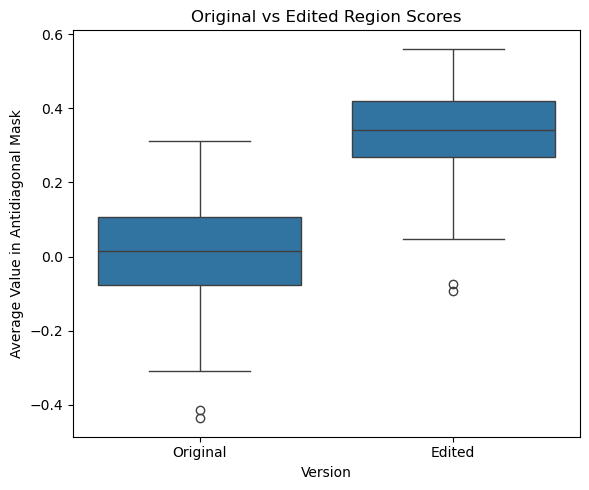

In [14]:
# Reshape to long format
plot_df = pd.melt(df, 
                  value_vars=['og_anti_diag30', 'ed_anti_diag30'],
                  var_name='Version', 
                  value_name='Score')

# Rename for prettier labels (optional)
plot_df['Version'] = plot_df['Version'].replace({
    'og_anti_diag30': 'Original',
    'ed_anti_diag30': 'Edited'
})

# Plot
plt.figure(figsize=(6, 5))
sns.boxplot(x='Version', y='Score', data=plot_df)
plt.ylabel('Average Value in Antidiagonal Mask')
plt.title('Original vs Edited Region Scores')
plt.tight_layout()
plt.show()


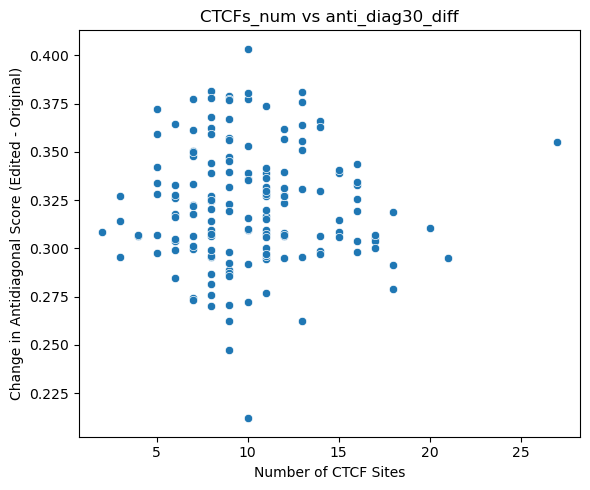

In [15]:

# Basic scatterplot
plt.figure(figsize=(6, 5))
sns.scatterplot(data=df, x='CTCFs_num', y='anti_diag30_diff')

plt.xlabel('Number of CTCF Sites')
plt.ylabel('Change in Antidiagonal Score (Edited - Original)')
plt.title('CTCFs_num vs anti_diag30_diff')
plt.tight_layout()
plt.show()

In [16]:
df.columns

Index(['chrom', 'start', 'end', 'fold', 'PearsonR', 'flat_start', 'flat_end',
       'centered_start', 'centered_end', 'centered_flat_start',
       'centered_flat_end', 'last_accepted_step', 'SCD', 'ed_anti_diag30',
       'og_anti_diag30', 'num_edits', 'GC_seq', 'GC_slice', 'GC_slice_edited',
       'init_CTCFs_num', 'CTCFs_num', 'FIMO_sum', 'FIMO_max', 'orientation',
       'positions', 'target', 'anti_diag30_diff'],
      dtype='object')

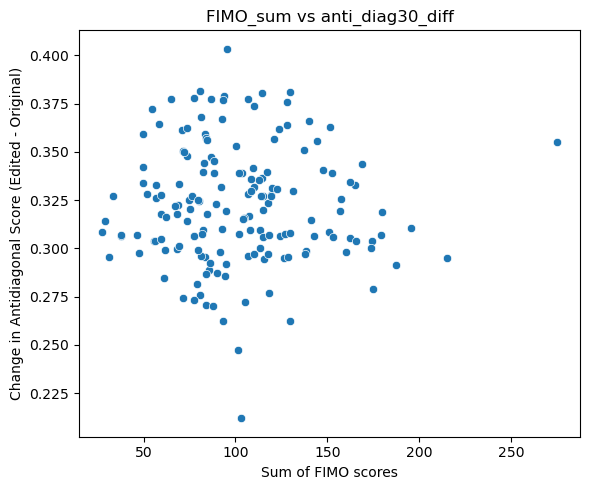

In [17]:
# Basic scatterplot
plt.figure(figsize=(6, 5))
sns.scatterplot(data=df, x='FIMO_sum', y='anti_diag30_diff')

plt.xlabel('Sum of FIMO scores')
plt.ylabel('Change in Antidiagonal Score (Edited - Original)')
plt.title('FIMO_sum vs anti_diag30_diff')
plt.tight_layout()
plt.show()

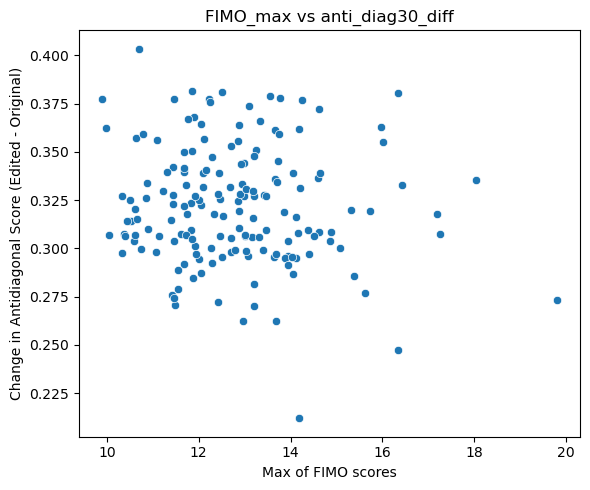

In [18]:
# Basic scatterplot
plt.figure(figsize=(6, 5))
sns.scatterplot(data=df, x='FIMO_max', y='anti_diag30_diff')

plt.xlabel('Max of FIMO scores')
plt.ylabel('Change in Antidiagonal Score (Edited - Original)')
plt.title('FIMO_max vs anti_diag30_diff')
plt.tight_layout()
plt.show()

In [19]:
df.columns

Index(['chrom', 'start', 'end', 'fold', 'PearsonR', 'flat_start', 'flat_end',
       'centered_start', 'centered_end', 'centered_flat_start',
       'centered_flat_end', 'last_accepted_step', 'SCD', 'ed_anti_diag30',
       'og_anti_diag30', 'num_edits', 'GC_seq', 'GC_slice', 'GC_slice_edited',
       'init_CTCFs_num', 'CTCFs_num', 'FIMO_sum', 'FIMO_max', 'orientation',
       'positions', 'target', 'anti_diag30_diff'],
      dtype='object')

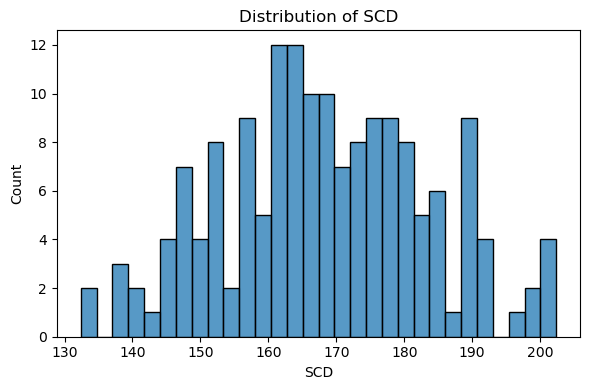

In [21]:
plt.figure(figsize=(6, 4))
sns.histplot(df['SCD'].dropna(), bins=30, kde=False)

plt.xlabel('SCD')
plt.ylabel('Count')
plt.title('Distribution of SCD')
plt.tight_layout()
plt.show()

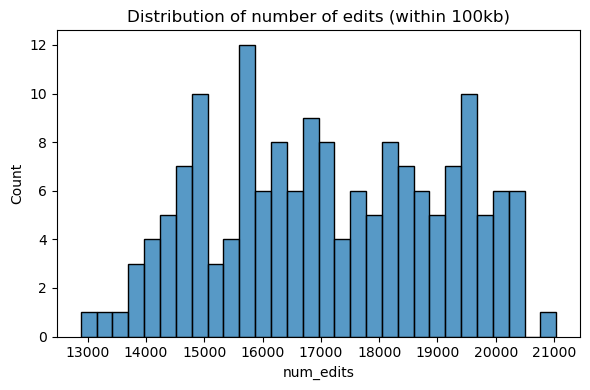

In [22]:
plt.figure(figsize=(6, 4))
sns.histplot(df['num_edits'].dropna(), bins=30, kde=False)

plt.xlabel('num_edits')
plt.ylabel('Count')
plt.title('Distribution of number of edits (within 100kb)')
plt.tight_layout()
plt.show()

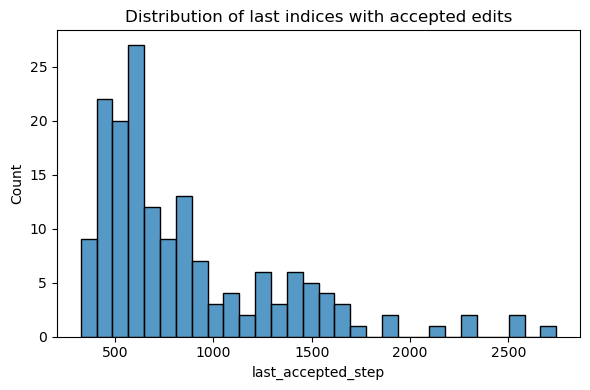

In [23]:
plt.figure(figsize=(6, 4))
sns.histplot(df['last_accepted_step'].dropna(), bins=30, kde=False)

plt.xlabel('last_accepted_step')
plt.ylabel('Count')
plt.title('Distribution of last indices with accepted edits')
plt.tight_layout()
plt.show()

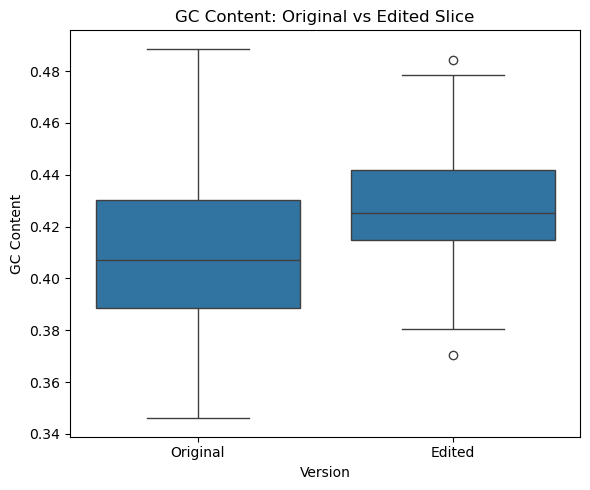

In [24]:
# Reshape to long format for plotting
plot_df = pd.melt(df,
                  value_vars=['GC_slice', 'GC_slice_edited'],
                  var_name='Version',
                  value_name='GC Content')

# Optional: rename columns for prettier x-axis labels
plot_df['Version'] = plot_df['Version'].replace({
    'GC_slice': 'Original',
    'GC_slice_edited': 'Edited'
})

# Plot
plt.figure(figsize=(6, 5))
sns.boxplot(data=plot_df, x='Version', y='GC Content')
plt.ylabel('GC Content')
plt.title('GC Content: Original vs Edited Slice')
plt.tight_layout()
plt.show()